# Load Data

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
transactions = pd.read_csv(r'C:\dev\SKN36-2nd-1Team\data\sampled\transactions_100k.csv')

In [6]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'].astype(int).astype(str),
    format = "%Y%m%d"
)

transactions['membership_expire_date'] = pd.to_datetime(
    transactions['membership_expire_date'].astype(int).astype(str),
    format = "%Y%m%d"
)

In [8]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122479 entries, 0 to 122478
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   msno                    122479 non-null  object        
 1   payment_method_id       122479 non-null  int64         
 2   payment_plan_days       122479 non-null  int64         
 3   plan_list_price         122479 non-null  int64         
 4   actual_amount_paid      122479 non-null  int64         
 5   is_auto_renew           122479 non-null  int64         
 6   transaction_date        122479 non-null  datetime64[ns]
 7   membership_expire_date  122479 non-null  datetime64[ns]
 8   is_cancel               122479 non-null  int64         
dtypes: datetime64[ns](2), int64(6), object(1)
memory usage: 8.4+ MB


In [11]:
transactions['payment_plan_days'].value_counts()

payment_plan_days
30     119054
410       649
90        512
195       454
180       418
7         225
60        222
0         206
240       179
360       168
100       115
120        96
395        39
10         28
200        24
400        21
1          19
365        19
450        13
70          6
31          3
415         3
14          3
270         2
230         1
Name: count, dtype: int64

In [10]:
transactions.groupby('payment_plan_days')['actual_amount_paid'].value_counts()

payment_plan_days  actual_amount_paid
0                  149                   156
                   119                    39
                   129                     7
                   100                     4
1                  0                      19
                                        ... 
400                1599                   21
410                1788                  647
                   0                       2
415                1599                    3
450                1788                   13
Name: count, Length: 61, dtype: int64

In [15]:
transaction_cnt = transactions.groupby('msno').size()
transaction_cnt.value_counts()

1     86021
2     11940
3      1122
4       201
5       201
6        81
7        54
8        47
11       37
10       28
21       28
13       24
12       23
9        22
14       18
15       14
19       12
22       12
17       12
23       10
26        8
20        8
28        7
16        7
25        6
35        6
24        6
30        5
18        5
33        4
36        4
27        4
34        4
39        3
29        3
48        3
38        2
37        2
45        2
61        1
31        1
54        1
40        1
Name: count, dtype: int64

# User Behavior df 만들기

In [17]:
trans = transactions.copy()

In [19]:
transaction_cnt = trans.groupby('msno').size().reset_index(name='transaction_cnt')
transaction_cnt.head()

,msno,transaction_cnt
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,1
1,++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=,2
2,++A8p4GrsTnMjI6hAZEtlRsaz6s6O9ddUoH0fmS4s7s=,1
3,++BW1PJYU5OZi3n3+IDLiU+d1IL1VE/GLx6p64TDs6U=,1
4,++L+G2jsvbkHMHlwvb2KQiRLAvB4VyEfjVJTUrs5auE=,1


In [ ]:
#거래 횟수가 1인 사람들의 비율 86%로 매우 높음 -> 거래 행동 변화 파악하기는 힘듦
(transaction_cnt['transaction_cnt'] == 1).mean()

np.float64(0.86021)

In [21]:
transaction_cnt['multiple_transaction'] = (transaction_cnt['transaction_cnt'] > 1).astype(int)
transaction_cnt.head()

,msno,transaction_cnt,multiple_transaction
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,1,0
1,++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=,2,1
2,++A8p4GrsTnMjI6hAZEtlRsaz6s6O9ddUoH0fmS4s7s=,1,0
3,++BW1PJYU5OZi3n3+IDLiU+d1IL1VE/GLx6p64TDs6U=,1,0
4,++L+G2jsvbkHMHlwvb2KQiRLAvB4VyEfjVJTUrs5auE=,1,0


### last transaction만 뽑아보기

In [22]:
last_trans = (
    trans.groupby('msno').tail(1).copy()
)

last_trans.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,2017-03-29,2017-03-31,1
1,+0W3Q9FSw8TLgoNke9JFl6dUeoxAOfuHarEexRPcJsA=,41,30,99,99,1,2017-03-18,2017-04-18,0
2,+5Yo2rxxC+x+kIYl4to0D1GTrKacKcaGG0sV38NLIn4=,34,30,149,149,1,2017-03-31,2017-04-30,0
3,+9WukYI6GOgOHx4YedRy4mVO/o6FgHl0tYWF8P9YwJU=,36,30,180,180,1,2017-03-06,2017-04-05,0
4,+DqGpEAXlGV0FgReAwwXrRSMeiwTNLHq1pkDCRZRjgA=,41,30,129,129,1,2017-03-01,2017-04-03,0


In [23]:
last_trans = last_trans.rename(
    columns={
        'payment_method_id': 'last_payment_method_id',
        'payment_plan_days': 'last_payment_plan_days',
        'plan_list_price': 'last_plan_list_price',
        'actual_amount_paid': 'last_actual_amount_paid',
        'is_auto_renew': 'last_is_auto_renew',
        'transaction_date': 'last_transaction_date',
        'membership_expire_date': 'last_membership_expire_date',
        'is_cancel': 'last_is_cancel'
    }
)

In [24]:
last_trans = last_trans[
    [
        'msno',
        'last_payment_plan_days',
        'last_plan_list_price',
        'last_actual_amount_paid',
        'last_is_auto_renew',
        'last_is_cancel'
    ]
]

In [25]:
last_trans['last_discount_amount'] = (
    last_trans['last_plan_list_price']
    - last_trans['last_actual_amount_paid']
)

In [26]:
last_trans['last_is_discount'] = (
    last_trans['last_actual_amount_paid']
    < last_trans['last_plan_list_price']
).astype(int)

In [27]:
last_trans.columns

Index(['msno', 'last_payment_plan_days', 'last_plan_list_price',
       'last_actual_amount_paid', 'last_is_auto_renew', 'last_is_cancel',
       'last_discount_amount', 'last_is_discount'],
      dtype='object')

In [28]:
user_behavior = last_trans.merge(
    transaction_cnt,
    on='msno',
    how='left'
)

In [29]:
user_behavior['last_is_auto_renew'].value_counts()

last_is_auto_renew
1    88787
0    11213
Name: count, dtype: int64

## is_churn과 결합

In [31]:
train = pd.read_csv(r'C:\dev\SKN36-2nd-1Team\data\sampled\train_100k.csv')

In [32]:
eda_df = train[
    ['msno', 'is_churn']
].merge(
    user_behavior,
    on='msno',
    how='left'
)

In [33]:
eda_df.isnull().sum()

msno                       0
is_churn                   0
last_payment_plan_days     0
last_plan_list_price       0
last_actual_amount_paid    0
last_is_auto_renew         0
last_is_cancel             0
last_discount_amount       0
last_is_discount           0
transaction_cnt            0
multiple_transaction       0
dtype: int64

In [34]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   msno                     100000 non-null  object
 1   is_churn                 100000 non-null  int64 
 2   last_payment_plan_days   100000 non-null  int64 
 3   last_plan_list_price     100000 non-null  int64 
 4   last_actual_amount_paid  100000 non-null  int64 
 5   last_is_auto_renew       100000 non-null  int64 
 6   last_is_cancel           100000 non-null  int64 
 7   last_discount_amount     100000 non-null  int64 
 8   last_is_discount         100000 non-null  int64 
 9   transaction_cnt          100000 non-null  int64 
 10  multiple_transaction     100000 non-null  int64 
dtypes: int64(10), object(1)
memory usage: 8.4+ MB


In [35]:
eda_df['is_churn'].mean()

np.float64(0.06422)

<Axes: xlabel='transaction_cnt', ylabel='Count'>

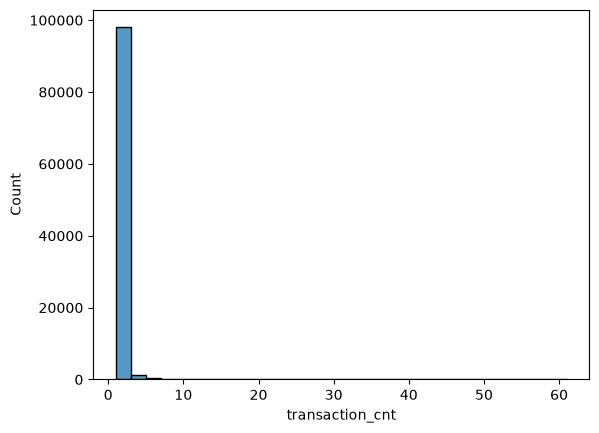

In [37]:
sns.histplot(data=eda_df, x='transaction_cnt', bins = 30)

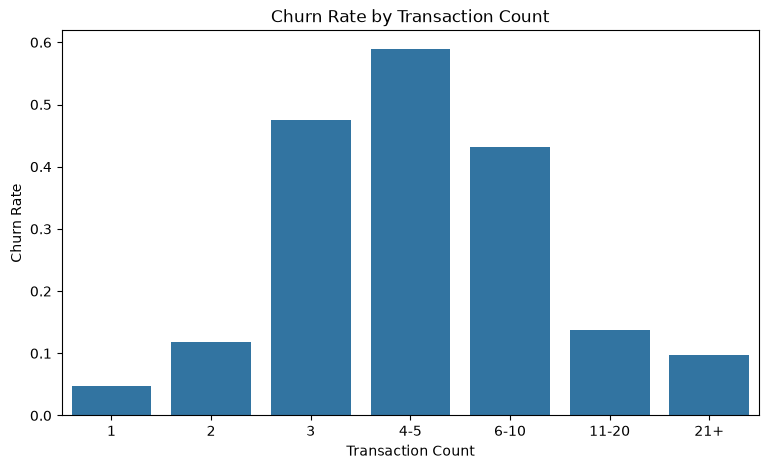

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bins = [0, 1, 2, 3, 5, 10, 20, float('inf')]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21+']

eda_df['transaction_cnt_group'] = pd.cut(
    eda_df['transaction_cnt'],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=eda_df,
    x='transaction_cnt_group',
    y='is_churn',
    errorbar=None
)

plt.xlabel('Transaction Count')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Transaction Count')

plt.show()

In [36]:
#multiple_transaction
eda_df.groupby('multiple_transaction')['is_churn'].agg(['mean', 'count'])

,mean,count
multiple_transaction,,
0,0.047826,86021
1,0.165105,13979


> 복수의 transaction 기록을 가진 고객군에서 이탈률이 상대적으로 높게 관찰되었다.

In [38]:
eda_df.groupby('is_churn')[
    ['last_plan_list_price', 'last_actual_amount_paid']
].agg(
    ['mean', 'median', 'std']
)

last_plan_list_price                    last_actual_amount_paid  \
                         mean median         std                    mean   
is_churn                                                                   
0                  133.589551  149.0   29.020587              133.396226   
1                  434.615540  149.0  525.370404              432.140610   

                             
         median         std  
is_churn                     
0         149.0   29.271131  
1         149.0  527.029341

> 표준 편차 커서 무의미할 수 있음

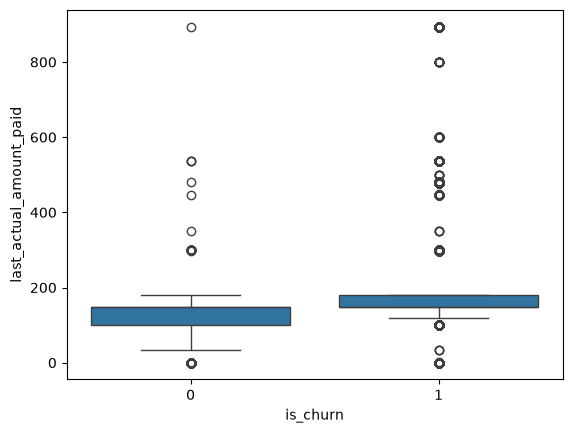

In [39]:
upper = eda_df['last_actual_amount_paid'].quantile(0.99)

sns.boxplot(
    data=eda_df[
        eda_df['last_actual_amount_paid'] <= upper
    ],
    x='is_churn',
    y='last_actual_amount_paid'
)

plt.show()

In [40]:
plan_summary = (
    eda_df.groupby('last_payment_plan_days')['is_churn']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'churn_rate'})
    .sort_values('count', ascending=False)
)

plan_summary.head(20)

,count,churn_rate
last_payment_plan_days,,
30,97548,0.041436
410,604,0.998344
195,430,0.997674
90,401,0.975062
180,376,0.992021
60,121,0.685950
100,112,0.991071
360,93,1.000000
240,76,0.986842


In [42]:
eda_df.groupby('transaction_cnt')['is_churn'].agg(
    ['count', 'mean']
).head(10)

,count,mean
transaction_cnt,,
1,86021,0.047826
2,11940,0.117588
3,1122,0.475045
4,201,0.572139
5,201,0.606965
6,81,0.358025
7,54,0.481481
8,47,0.468085
9,22,0.500000


In [43]:
eda_df.groupby('last_is_auto_renew')['is_churn'].agg(
    ['count', 'mean']
)

,count,mean
last_is_auto_renew,,
0,11213,0.303041
1,88787,0.034059


In [44]:
eda_df.groupby('last_is_discount')['is_churn'].agg(
    ['count', 'mean']
)

,count,mean
last_is_discount,,
0,99709,0.063364
1,291,0.357388


> 최근 정가보다 낮은 금액을 결제한 고객의 이탈률은 약 41.0%로, 정상가 이상을 결제한 고객의 약 6.1%보다 크게 높게 나타났다. 다만 할인 거래 고객의 표본이 전체 고객 중 매우 적으므로, 할인 자체의 영향으로 해석하기보다는 해당 집단의 플랜·결제 방식·자동갱신 및 취소 특성을 추가로 확인할 필요가 있다.

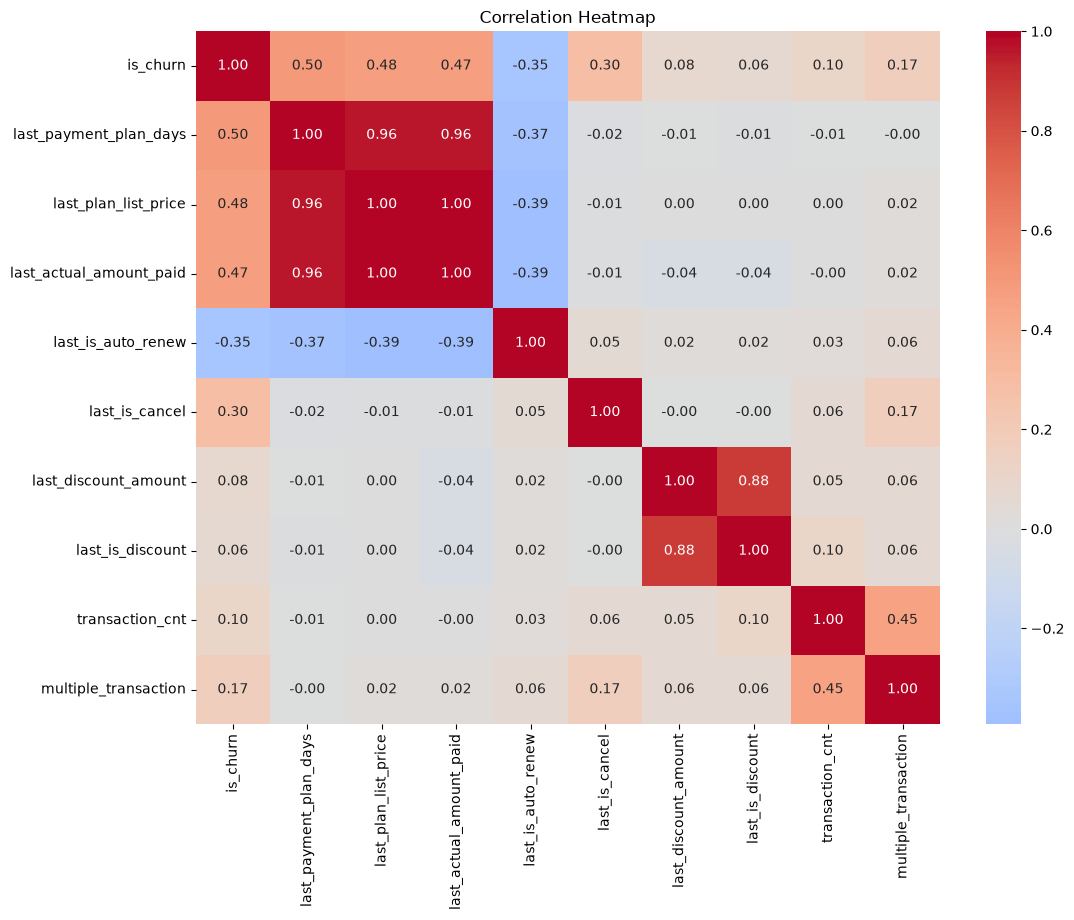

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# msno 제거
corr_df = eda_df.drop(columns='msno')

# 숫자형 컬럼만 선택
corr = corr_df.select_dtypes(include='number').corr()

# heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,       # 상관계수 숫자 표시
    fmt='.2f',        # 소수점 둘째 자리
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()